In [ ]:
import pandas as pd

#gives me 2 decimal for every float
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.options.display.max_rows = 1000

# Importing CSVs

In [ ]:
url = 'https://drive.google.com/file/d/1afxwDXfl-7cQ_qLwyDitfcCx3u7WMvkU/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


product_df = pd.read_csv(path)

In [ ]:
url = 'https://drive.google.com/file/d/1Vu0q91qZw6lqhIqbjoXYvYAQTmVHh6uZ/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


order_df = pd.read_csv(path)

In [ ]:
url = 'https://drive.google.com/file/d/1FYhN_2AzTBFuWcfHaRuKcuCE6CWXsWtG/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


orderline_df = pd.read_csv(path)

In [ ]:
url = 'https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]


brands_df = pd.read_csv(path)

## Creating copies of DF

In [ ]:
brands_copy = brands_df.copy()
orderline_copy = orderline_df.copy()
order_copy = order_df.copy()
product_copy = product_df.copy()

In [ ]:
product_copy.isna().sum()

,0
sku,0
name,0
desc,7
price,46
promo_price,0
in_stock,0
type,50


## Observing Data

In [ ]:
order_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [ ]:
product_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


# Cleaning

## Filter Completed state

In [ ]:
# we keep only Completed orders
order_df = order_df.loc[order_df['state'] == 'Completed']

## Delete columns/rows

In [ ]:
# all duplicates and rows containing NaN rows are deleted
product_df = product_df.drop_duplicates(subset='sku')

In [ ]:
# delete unused column
orderline_df = orderline_df.drop('product_id',axis=1)

In [ ]:
# delete promo_price irrelevant + contains many value errors
# delete type --> Those numbers represent nothing meaningfull
# delete desc --> similar to name anyway
product_df = product_df.drop(['promo_price','in_stock'],axis=1)

In [ ]:
# decision: delete these 5% instances of double periods in price rows in products
product_df = product_df.loc[~((product_df.price.str.contains(r"\d+\.\d+\.\d+"))|(product_df.price.str.contains(r"\d+\.\d{3,}"))), :]

In [ ]:
# 257 814 rows have error values - 12.3% of all rows
orderline_df.unit_price.str.contains(r"\d+\.\d+\.\d+").value_counts()

,count
unit_price,
False,257814
True,36169


In [ ]:
# decision: delete these 12.3% of the rows in our orderline_df
orderline_df = orderline_df.loc[~((orderline_df.unit_price.str.contains(r"\d+\.\d+\.\d+"))|(orderline_df.unit_price.str.contains(r"\d+\.\d{3,}"))), :]

In [ ]:
# 5 rows found null in total_paid
order_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46605 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      46605 non-null  int64  
 1   created_date  46605 non-null  object 
 2   total_paid    46605 non-null  float64
 3   state         46605 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.8+ MB


In [ ]:
order_df = order_df.drop('state',axis=1)

In [ ]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46605 entries, 1 to 226619
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      46605 non-null  int64  
 1   created_date  46605 non-null  object 
 2   total_paid    46605 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.4+ MB


In [ ]:
#renaming to merge better
orderline_df = orderline_df.rename(columns={'id_order':'order_id'})

In [ ]:
#delete those empty rows
order_df = order_df.dropna(axis=0)

In [ ]:
#5 rows are empty in total_paid
order_df.isna().sum()

,0
order_id,0
created_date,0
total_paid,0


## Renaming columns

In [ ]:
orderline_df = orderline_df.rename(columns = {'product_quantity':'quantity'})

# Converting Dtypes


## Convert to Datetime

In [ ]:
order_df["created_date"] = pd.to_datetime(order_df["created_date"])

In [ ]:
orderline_df["date"] = pd.to_datetime(orderline_df["date"])

## Converting to float.
Error values?

In [ ]:
orderline_df['unit_price'] = pd.to_numeric(orderline_df['unit_price'])

### Product converting + deleting

In [ ]:
# convert all weird values with double '.'  to NaN
product_df['price'] = pd.to_numeric(product_df['price'], errors='coerce')

In [ ]:
# drop all NaN values
product_df = product_df.dropna(axis=0)

# Final info

In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9940 entries, 0 to 19325
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sku     9940 non-null   object 
 1   name    9940 non-null   object 
 2   desc    9940 non-null   object 
 3   price   9940 non-null   float64
 4   type    9940 non-null   object 
dtypes: float64(1), object(4)
memory usage: 465.9+ KB


In [ ]:
orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257814 entries, 0 to 293982
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id          257814 non-null  int64         
 1   order_id    257814 non-null  int64         
 2   quantity    257814 non-null  int64         
 3   sku         257814 non-null  object        
 4   unit_price  257814 non-null  float64       
 5   date        257814 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 13.8+ MB


In [ ]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46605 entries, 1 to 226619
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      46605 non-null  int64         
 1   created_date  46605 non-null  datetime64[ns]
 2   total_paid    46605 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.4 MB


# Data Quality Assessment

## Keep only the orders that are present in both `orders` and `orderlines`

In [ ]:
#let's find each their unique order_id count
order_df["order_id"].nunique()
# 46605

46605

In [ ]:
orderline_df["order_id"].nunique()
# 186822

186822

Huge differce
We want to make sure that every order_id in both dateframes

### Merge order_orderline

In [ ]:
order_orderline = order_df.merge(orderline_df,
                                 on = 'order_id',
                                 how="inner")
order_orderline.shape
# shape(58542, 8)



(58542, 8)

In [ ]:
# order_ids that are in both tables
order_id = order_orderline["order_id"].unique()

In [ ]:
#array of values
order_id

array([241423, 242832, 243330, ..., 527074, 527096, 527112])

In [ ]:
# we only keep those from the merge in the original order
order_df = order_df.loc[order_df["order_id"].
                        isin(order_id), :]

# we only keep those from the merge in the original orderline
orderline_df = orderline_df.loc[orderline_df["order_id"].
                                isin(order_id), :]

### Last check if order & orderline are matching


In [ ]:
order_df["order_id"].nunique(), orderline_df["order_id"].nunique()

(44113, 44113)

IT'S A MATCH !

##Exclude unknown products


### Merge product_orderline



In [ ]:
product_orderline = orderline_df.merge(product_df,
                                       on = 'sku',
                                       how = 'left')[["order_id","sku","name" ]]
# we only need 3 columns

product_orderline.shape
# (58542, 3)


(58542, 3)

Is there any NaN

In [ ]:
product_orderline.isna().sum()
# 1495 name missing

,0
order_id,0
sku,0
name,1511


### We need to remove the name but also delete all the order corresponding
--> Domino effect.

In [ ]:
orders_to_delete = product_orderline.loc[product_orderline["name"].isna(), "order_id"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363])

### We remove those orders from Order_df + Orderline_df

In [ ]:
order_df = order_df.loc[~order_df["order_id"].isin(orders_to_delete),:]
orderline_df = orderline_df.loc[~orderline_df["order_id"].isin(orders_to_delete),:]

In [ ]:
# filtering both DataFrame with unique order_ids
# it's a match (42649, 42649)

order_df["order_id"].nunique(), orderline_df["order_id"].nunique()

(42633, 42633)

In [ ]:
merge_test = orderline_df.merge(product_df,
                                on = 'sku',
                                how= 'left')
merge_test.isna().sum()
# no NAN

,0
id,0
order_id,0
quantity,0
sku,0
unit_price,0
date,0
name,0
desc,0
price,0
type,0


# Copy DateFrame

In [ ]:
order_df_qu = order_df.copy()
orderline_df_qu =orderline_df.copy()

## Create Column

In [ ]:
#By definition, should be representative of all orders' total
orderline_df['unit_price_paid'] = orderline_df['unit_price'] * orderline_df['quantity']

## Create a new Serie - Groupby

In [ ]:
order_orderline_id = orderline_df.groupby("order_id", as_index=False)["unit_price_paid"].sum()
# as_index=False changes the return so that the groupedby column remains a column (not the index)

# New merge with updated orders and orderlines (groupby)
We removed all orders that were not in both DF

In [ ]:
diff_amount_df = order_df.merge(order_orderline_id,
                                on = 'order_id',
                                how = 'inner')
diff_amount_df

,order_id,created_date,total_paid,unit_price_paid
0,241423,2017-11-06 13:10:02,136.15,129.16
1,242832,2017-12-31 17:40:03,15.76,10.77
2,243330,2017-02-16 10:59:38,84.98,77.99
3,245275,2017-06-28 11:35:37,149.00,149.00
4,245595,2017-01-21 12:52:47,112.97,105.98
...,...,...,...,...
42628,527042,2018-03-14 11:47:50,18.98,13.99
42629,527070,2018-03-14 11:50:48,24.97,19.98
42630,527074,2018-03-14 11:51:42,24.97,19.98
42631,527096,2018-03-14 11:58:40,34.96,29.97


### Create column for difference

In [ ]:
diff_amount_df["difference"] = diff_amount_df["total_paid"] - diff_amount_df["unit_price_paid"]
diff_amount_df

,order_id,created_date,total_paid,unit_price_paid,difference
0,241423,2017-11-06 13:10:02,136.15,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,105.98,6.99
...,...,...,...,...,...
42628,527042,2018-03-14 11:47:50,18.98,13.99,4.99
42629,527070,2018-03-14 11:50:48,24.97,19.98,4.99
42630,527074,2018-03-14 11:51:42,24.97,19.98,4.99
42631,527096,2018-03-14 11:58:40,34.96,29.97,4.99


## Distribution

In [ ]:
# Distribution:
diff_amount_df['difference'].describe()

,difference
count,42633.00
mean,51.92
std,351.85
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,9065.96


Range(-165 - 9065) --> outliers showing odd data

Quartile are:
25%: 0
50%: 4.99 (postage)
75%: 6.99e (postage fast delivery or package or distance)


### Outliers exclusion

In [ ]:
# we know that
Qu1 = 0
Qu3 = 6.99
IQR = Qu3-Qu1


In [ ]:
# calculate the lower boundary = outlier : Qu1 - 1.5 * IQR
# = -10.485
Qu1 - 1.5 * IQR
# calculate the upper boundary = outlier: Qu3- 1.5 * IQR
# = -3.5
Qu3- 1.5 * IQR

-3.494999999999999

### New DataFrame filtering those out of the boundary

In [ ]:
diff_no_outliers_df = diff_amount_df.loc[
    (diff_amount_df["difference"] >= (Qu1 - 1.5*IQR))
    &
    (diff_amount_df["difference"] <= (Qu3 + 1.5*IQR))
    ,
    :]
diff_no_outliers_df.difference.describe()
# min = -5
# max = 16.97
# average = 3.94
# range is now more explicable

,difference
count,40971.00
mean,3.94
std,2.83
min,-5.00
25%,0.00
50%,4.99
75%,6.99
max,16.97


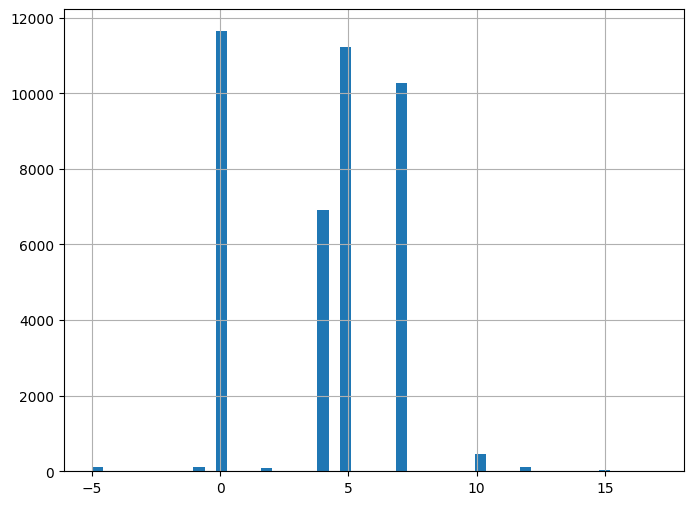

In [ ]:
# let's visualize how is this distribution on a plot
diff_no_outliers_df.difference.hist(bins= 50, figsize=(8,6));

In [ ]:
# New Serie with only Order_id to remove them from the Merge
Serie_diff_no_outliers = diff_no_outliers_df['order_id']
Serie_diff_no_outliers

,order_id
0,241423
1,242832
2,243330
3,245275
4,245595
...,...
42628,527042
42629,527070
42630,527074
42631,527096


In [ ]:
order_df = order_df.loc[order_df["order_id"].isin(Serie_diff_no_outliers), :]
orderline_df = orderline_df.loc[orderline_df["order_id"].isin(Serie_diff_no_outliers), :]

In [ ]:
# check if they're still matching. YES !
order_df["order_id"].nunique(), orderline_df["order_id"].nunique()

(40971, 40971)

### Download Quality Controlled DataFrames

In [ ]:
from google.colab import files
order_df.to_csv('order_df.csv', index=False)
files.download("order_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
orderline_df.to_csv('orderline_df.csv', index=False)
files.download("orderline_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
product_df.to_csv('product_df.csv', index=False)
files.download("product_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53210 entries, 7 to 293661
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               53210 non-null  int64         
 1   order_id         53210 non-null  int64         
 2   quantity         53210 non-null  int64         
 3   sku              53210 non-null  object        
 4   unit_price       53210 non-null  float64       
 5   date             53210 non-null  datetime64[ns]
 6   unit_price_paid  53210 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 3.2+ MB


In [ ]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40971 entries, 1 to 226619
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40971 non-null  int64         
 1   created_date  40971 non-null  datetime64[ns]
 2   total_paid    40971 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.3 MB


In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9940 entries, 0 to 19325
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sku     9940 non-null   object 
 1   name    9940 non-null   object 
 2   desc    9940 non-null   object 
 3   price   9940 non-null   float64
 4   type    9940 non-null   object 
dtypes: float64(1), object(4)
memory usage: 465.9+ KB
